# IdiomX – Task 2: Context-to-Idiom Retrieval (Main Benchmark)

This notebook presents the main **Task 2** benchmark for **IdiomX** using the **high-quality dataset split**.

## Task definition

Given an **English idiomatic contextual sentence**, the goal is to retrieve the correct **canonical idiom** from a fixed idiom inventory.

This is a **closed-set retrieval task**:
- input: idiomatic contextual sentence
- output: canonical idiom
- prediction space: fixed idiom bank

## Experimental design

This notebook is intentionally kept clean and publication-ready.

It uses:
- one **final query-level leakage-safe split strategy**
- one **strong baseline**
- one **best final model**

The two evaluated systems are:
1. **MiniLM dense retrieval**
2. **Hybrid retrieval with cross-encoder reranking**

## Evaluation metrics

We report:
- **Top-1 Accuracy**
- **Top-3 Accuracy**
- **Top-5 Accuracy**
- **Mean Reciprocal Rank (MRR)**

The notebook is designed for:
- reproducibility
- clean research reporting
- GitHub publication
- direct integration into the research paper

In [82]:
# [1.1] Environment setup and reproducibility

from pathlib import Path
import warnings
import random
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

print("Environment setup complete.")
print(f"Random seed: {SEED}")

Environment setup complete.
Random seed: 42


In [83]:
# [2.1] Load IdiomX high-quality dataset (minimal output)

from datasets import load_dataset

HF_DATASET_ID = "aymansharara/IdiomX"
CONFIG_NAME = "idiomx_high_quality"

dataset = load_dataset(HF_DATASET_ID, CONFIG_NAME)

print("Dataset loaded successfully.")
print("Available splits:", list(dataset.keys()))

Dataset loaded successfully.
Available splits: ['idiomx_high_quality_train', 'idiomx_high_quality_test']


In [84]:
# [2.2] Inspect dataset structure (light preview)

df = dataset[list(dataset.keys())[0]].to_pandas()

print("Shape:", df.shape)
print("Columns:", list(df.columns))

df.head(2)

Shape: (98413, 52)
Columns: ['idiom_id', 'idiom_canonical', 'example', 'example_usage_label', 'idiom_canonical_meaning', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'example_raw', 'example_language', 'source', 'source_type', 'source_url', 'record_origin', 'license_source', 'idiom_surface', 'pos', 'tags', 'idiom_confidence', 'is_example_idiom', 'is_generated_example', 'is_adversarial_example', 'meaning_language', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_in_example_arabic', 'enrichment_model', 'enrichment_version', 'validation_status', 'context_type', 'source_style', 'hard_negative_idioms', 'meaning_paraphrases_en', 'meaning_paraphrases_ar', 'idiom_level_explanation_en', 'idiom_level_explanation_ar', 'explanation_en', 'explanation_ar', 'minimal_pair_id', 'paraphrase_group_id', 'adversarial_type', 'expected_label', 'row_type', 'example_normalized', 's

,idiom_id,idiom_canonical,example,example_usage_label,idiom_canonical_meaning,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,example_raw,example_language,source,source_type,source_url,record_origin,license_source,idiom_surface,pos,tags,idiom_confidence,is_example_idiom,is_generated_example,is_adversarial_example,meaning_language,idiom_canonical_meaning_arabic,is_idiom,ambiguity_flag,idiom_compositionality_level,idiom_register,idiom_domain,learner_difficulty,idiom_in_example_arabic,enrichment_model,enrichment_version,validation_status,context_type,source_style,hard_negative_idioms,meaning_paraphrases_en,meaning_paraphrases_ar,idiom_level_explanation_en,idiom_level_explanation_ar,explanation_en,explanation_ar,minimal_pair_id,paraphrase_group_id,adversarial_type,expected_label,row_type,example_normalized,sentence_length_chars,sentence_length_words,semantic_similarity_example_vs_meaning,semantic_quality
0,idiomx_543ff4605a0e,'ark at 'ee,Please ’ark at ’ee the microchip here to observe the auditory sensor’s location.,literal,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Literal direction to look at the specific part corresponding to an ear on a device.,توجيه حرفي للنظر إلى جزء معين يشبه الأذن في جهاز.,"‘Look at that water! No wonder Duddle said he wouldn’t dare take the raft down this way; it’s dreadful!’ / Togget pointed ahead. ‘Yurr oi think et wursens yonder, ’ark at ee roaren et makes!’",en,kaikki_wiktionary,dictionary,NaN,llm_enriched_v2,wiktionary_cc_by_sa_4_0,'ark at 'ee,phrase,informal,high,False,1,0,en,"تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أو للتعبير عن الدهشة من كلامه، بمعنى ""استمع إلى ما تقول!"" أو ""انظر إلى ذلك!""",True,strongly_idiomatic,opaque,informal,regional,hard,يرجى النظر إلى الأذن في هذه الشريحة الإلكترونية لمراقبة موقع حساس السمع.,gpt-4.1-mini-2025-04-14,v2,valid,formal,synthetic_narrative,"[""listen up"", ""hear me out"", ""look who's talking""]","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]","[""انتبه إلى ما يقال"", ""استمع إلى ذلك القول المفاجئ"", ""اعتبر كلمات المتحدث""]",This phrase is idiomatic because it uses dialectal contraction and an exclamatory phrase that does not literally mean to physically 'look at the ear' but instead commands attention to someone's sp...,"هذه العبارة تعبير مجازي لأنها تستخدم اختصارًا لهجة وعبارة تعجبية لا تعني حرفيًا ""انظر إلى الأذن"" بل تأمر بالانتباه إلى كلام أو رأي شخص ما.",Literal technical instruction without figurative meaning.,تعليمات حرفية تقنية بدون معنى مجازي.,pair_0bd2fe08fbde,paraphrase_6a8ebd5786f7,None,literal,main_example,please ark at ee the microchip here to observe the auditory sensors location,80,13,0.522272,high
1,idiomx_543ff4605a0e,'ark at 'ee,Can you ’ark at ’ee how clear the sound is from my new headphones? #literal,literal,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Literal use describing sound clarity near the ear.,استخدام حرفي يصف وضوح الصوت بالقرب من الأذن.,"‘Look at that water! No wonder Duddle said he wouldn’t dare take the raft down this way; it’s dreadful!’ / Togget pointed ahead. ‘Yurr oi think et wursens yonder, ’ark at ee roaren et makes!’",en,kaikki_wiktionary,dictionary,NaN,llm_enriched_v2,wiktionary_cc_by_sa_4_0,'ark at 'ee,phrase,informal,high,False,1,0,en,"تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أو للتعبير عن الدهشة من كلامه، بمعنى ""استمع إلى ما تقول!"" أو ""انظر إلى ذلك!""",True,strongly_idiomatic,opaque,informal,regional,hard,هل يمكنك النظر إلى الأذن كيف واضح الصوت من سماعاتي الجديدة؟ #حرفي,gpt-4.1-mini-2025-04-14,v2,valid,social_media,synthetic_narrative,"[""listen up"", ""hear me out"", ""look who's talking""]","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Co

In [85]:
# [2.3] Build a compact working dataframe for Task 2

task2_df = df[
    [
        "idiom_id",
        "idiom_canonical",
        "example",
        "example_usage_label",
        "is_example_idiom",
        "validation_status",
        "semantic_quality",
    ]
].copy()

print("Task 2 base dataframe created.")
print("Shape:", task2_df.shape)

Task 2 base dataframe created.
Shape: (98413, 7)


In [86]:
# [2.4] Quick preview

task2_df.head(3)

,idiom_id,idiom_canonical,example,example_usage_label,is_example_idiom,validation_status,semantic_quality
0,idiomx_543ff4605a0e,'ark at 'ee,Please ’ark at ’ee the microchip here to observe the auditory sensor’s location.,literal,False,valid,high
1,idiomx_543ff4605a0e,'ark at 'ee,Can you ’ark at ’ee how clear the sound is from my new headphones? #literal,literal,False,valid,high
2,idiomx_543ff4605a0e,'ark at 'ee,Can you ’ark at ’ee the diagram to find the auditory nerve?,literal,False,valid,high


In [87]:
# [2.5] Validate is_example_idiom field

print("Null count:", task2_df["is_example_idiom"].isna().sum())

print("\nValue distribution:")
print(task2_df["is_example_idiom"].value_counts(dropna=False, normalize=True))

Null count: 4902

Value distribution:
is_example_idiom
False    0.538404
True     0.411785
None     0.049810
Name: proportion, dtype: float64


In [88]:
# [2.6] Consistency check: label vs is_example_idiom

pd.crosstab(
    task2_df["example_usage_label"],
    task2_df["is_example_idiom"],
    normalize="index"
)

is_example_idiom,False,True
example_usage_label,,
borderline,0.000000,1.000000
idiomatic,0.000025,0.999975
literal,0.999849,0.000151


In [89]:
# [3.1] Filter to clean idiomatic Task 2 dataset

filtered_df = task2_df[
    (task2_df["is_example_idiom"] == True) &
    (task2_df["validation_status"] == "valid") &
    (task2_df["semantic_quality"] == "high")
].copy()

print("Filtered dataset shape:", filtered_df.shape)

Filtered dataset shape: (38604, 7)


In [90]:
# [3.2] Sanity checks

print("Unique idioms:", filtered_df["idiom_canonical"].nunique())
print("Examples:", len(filtered_df))

filtered_df.head(3)

Unique idioms: 11626
Examples: 38604


,idiom_id,idiom_canonical,example,example_usage_label,is_example_idiom,validation_status,semantic_quality
3,idiomx_7fd1dd45c159,'fraid so,"'Fraid so, the meeting's been canceled.",idiomatic,True,valid,high
4,idiomx_7fd1dd45c159,'fraid so,"When asked if the project was delayed, he said, ''fraid so.'",idiomatic,True,valid,high
8,idiomx_dd41993ed905,110 proof,This new coffee blend is 110 proof in caffeine kick.,idiomatic,True,valid,high


In [91]:
# [4.1] Shuffle dataset (important before splitting)

filtered_df = filtered_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Shuffled dataset.")

Shuffled dataset.


### Split Strategy

We use a query-level split:
- sentences are split randomly
- idioms may appear in both splits
- no sentence leakage between train and test

This reflects a realistic closed-set retrieval setup.

In [12]:
# [4.2] Train / Test split (query-level)

split_ratio = 0.8
split_idx = int(len(filtered_df) * split_ratio)

train_df = filtered_df.iloc[:split_idx].copy()
test_df  = filtered_df.iloc[split_idx:].copy()

print("Train size:", len(train_df))
print("Test size :", len(test_df))

Train size: 30883
Test size : 7721


In [92]:
# [4.3] Split sanity checks

print("Train unique idioms:", train_df["idiom_canonical"].nunique())
print("Test unique idioms :", test_df["idiom_canonical"].nunique())

overlap = set(train_df["idiom_canonical"]).intersection(set(test_df["idiom_canonical"]))
print("Shared idioms between splits:", len(overlap))

Train unique idioms: 11223
Test unique idioms : 5759
Shared idioms between splits: 5356


### Idiom Bank

A fixed idiom inventory is constructed from all unique canonical idioms.

Each idiom is assigned a unique index, enabling retrieval evaluation as a ranking task over the full idiom set.

In [93]:
# [5.1] Build idiom bank (unique canonical idioms)

idiom_bank = (
    filtered_df[["idiom_canonical"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Idiom bank size:", len(idiom_bank))

Idiom bank size: 11626


### Creating Idiom Index Mapping

We assign each idiom a unique numeric index.

This makes evaluation easier because the retrieval target can be represented as a single label instead of raw text.

In [95]:
# [5.2] Create idiom → index mapping

idiom_to_idx = {idiom: i for i, idiom in enumerate(idiom_bank["idiom_canonical"])}
idx_to_idiom = {i: idiom for idiom, i in idiom_to_idx.items()}

print("Mapping created.")

Mapping created.


### Assigning Target Labels

We map the gold idiom of each train and test example to its numeric index.

These target indices will be used later to evaluate whether retrieval returns the correct idiom.

In [96]:
# [5.3] Convert targets to indices

train_df["target"] = train_df["idiom_canonical"].map(idiom_to_idx)
test_df["target"]  = test_df["idiom_canonical"].map(idiom_to_idx)

print("Targets assigned.")

Targets assigned.


### Loading the Dense Retrieval Model

We load MiniLM as the main dense retrieval baseline.

This model converts both sentences and idioms into embeddings that can be compared in the same semantic space.

In [98]:
# [6.1] Load MiniLM sentence embedding model

from sentence_transformers import SentenceTransformer

model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(model_name)

print("MiniLM model loaded.")

MiniLM model loaded.


### Encoding Idiom Bank

We encode all canonical idioms into dense vector representations using MiniLM.

These embeddings form the fixed retrieval index, allowing us to compare each query sentence against all candidate idioms using similarity.

In [99]:
# [6.2] Encode idiom bank (canonical idioms)

idiom_texts = idiom_bank["idiom_canonical"].tolist()

idiom_embeddings = embedder.encode(
    idiom_texts,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Idiom embeddings shape:", idiom_embeddings.shape)

Batches: 100%|███████████████████████████████████████████████████████████████████████| 364/364 [00:07<00:00, 51.32it/s]


Idiom embeddings shape: (11626, 384)


### Encoding Query Sentences

We encode each test sentence into a vector representation.

These query embeddings will be compared against the idiom bank to retrieve the most similar idioms.

In [100]:
# [6.3] Encode test queries

test_texts = test_df["example"].tolist()

test_embeddings = embedder.encode(
    test_texts,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Test embeddings shape:", test_embeddings.shape)

Batches: 100%|███████████████████████████████████████████████████████████████████████| 242/242 [00:04<00:00, 48.44it/s]


Test embeddings shape: (7721, 384)


### Computing Dense Similarity

We compare each query embedding with all idiom embeddings.

This produces a similarity score for every query–idiom pair, which is then used for ranking.

In [101]:
# [6.4] Compute similarity matrix (cosine similarity via dot product)

similarity_matrix = np.dot(test_embeddings, idiom_embeddings.T)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (7721, 11626)


### Evaluating Dense Retrieval

We rank idioms by similarity and measure whether the correct idiom appears among the top predictions.

This gives the main retrieval metrics: Top-1, Top-3, Top-5, and MRR.

In [102]:
# [6.5] Evaluate retrieval (Top-k + MRR)

targets = test_df["target"].values

top_k = [1, 3, 5]
correct_at_k = {k: 0 for k in top_k}
mrr_total = 0

for i in range(len(similarity_matrix)):
    scores = similarity_matrix[i]
    ranked_indices = np.argsort(-scores)  # descending

    target = targets[i]

    # Top-k accuracy
    for k in top_k:
        if target in ranked_indices[:k]:
            correct_at_k[k] += 1

    # MRR
    rank = np.where(ranked_indices == target)[0][0] + 1
    mrr_total += 1.0 / rank

# Final metrics
results = {
    f"Top-{k} Accuracy": correct_at_k[k] / len(similarity_matrix)
    for k in top_k
}
results["MRR"] = mrr_total / len(similarity_matrix)

results

{'Top-1 Accuracy': 0.5374951431161766,
 'Top-3 Accuracy': 0.662608470405388,
 'Top-5 Accuracy': 0.7065147001683719,
 'MRR': 0.6175072931770659}

### MiniLM Baseline Results

- Top-1 Accuracy: 0.537
- Top-3 Accuracy: 0.663
- Top-5 Accuracy: 0.707
- MRR: 0.618

MiniLM provides a strong dense retrieval baseline, showing that contextual embeddings capture idiomatic meaning reasonably well, but still leave room for improvement.

---

### Preparing the Lexical Retrieval Component

We add BM25 as a lexical retrieval model.

Unlike MiniLM, BM25 focuses on token overlap, which can help when the query shares important words with the target idiom.

### Hybrid Retrieval Setup

We combine:
- dense similarity (MiniLM)
- lexical similarity (BM25)

This helps capture both semantic meaning and exact phrase overlap, improving retrieval performance.

In [103]:
# [7.1] Ensure BM25 is available (reproducible setup)

import sys
import subprocess

try:
    from rank_bm25 import BM25Okapi
    print("BM25 already installed.")
except ImportError:
    print("Installing rank_bm25...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rank_bm25"])
    from rank_bm25 import BM25Okapi
    print("BM25 installed and imported.")

BM25 already installed.


### Building the BM25 Index

We build a lexical retrieval index over the idiom bank.

BM25 complements dense retrieval by rewarding exact token overlap between the query and candidate idioms.

In [104]:
# [7.2] Build BM25 index over canonical idioms

idiom_tokens = [idiom.lower().split() for idiom in idiom_texts]
bm25 = BM25Okapi(idiom_tokens)

print("BM25 index ready.")
print("Indexed idioms:", len(idiom_tokens))

BM25 index ready.
Indexed idioms: 11626


### Computing Hybrid Scores

We combine MiniLM and BM25 scores for each query.

This allows the model to use both semantic similarity and lexical overlap when ranking idioms.

In [105]:
# [7.3] Compute hybrid similarity scores with progress tracking

# Ensure tqdm is available (for progress bar)
try:
    from tqdm.auto import tqdm
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tqdm"])
    from tqdm.auto import tqdm


# Normalize scores to [0, 1] range
def minmax_normalize(scores):
    scores = np.asarray(scores, dtype=float)
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)


# Copy MiniLM similarity (dense retrieval scores)
minilm_test_similarity = similarity_matrix.copy()

# Initialize hybrid matrix (same shape)
hybrid_test_similarity = np.zeros_like(minilm_test_similarity)


# Loop over each test query
for i, query_text in enumerate(tqdm(test_texts, desc="Computing hybrid scores")):

    # Dense similarity from MiniLM
    dense_scores = minilm_test_similarity[i]

    # BM25 lexical scores (based on token overlap)
    bm25_scores = np.array(
        bm25.get_scores(query_text.lower().split()),
        dtype=float
    )

    # Normalize both score types
    dense_scores_norm = minmax_normalize(dense_scores)
    bm25_scores_norm = minmax_normalize(bm25_scores)

    # Combine scores (equal weighting)
    hybrid_test_similarity[i] = (
        0.5 * dense_scores_norm +
        0.5 * bm25_scores_norm
    )


print("Hybrid similarity matrix shape:", hybrid_test_similarity.shape)

Computing hybrid scores: 100%|█████████████████████████████████████████████████████| 7721/7721 [06:19<00:00, 20.35it/s]

Hybrid similarity matrix shape: (7721, 11626)


### Evaluating Hybrid Retrieval

We evaluate the hybrid model using the same metrics as MiniLM.

This allows direct comparison to measure the impact of combining dense and lexical signals.

In [106]:
# [7.4] Evaluate hybrid retrieval

targets = test_df["target"].values

top_k = [1, 3, 5]
correct_at_k = {k: 0 for k in top_k}
mrr_total = 0

# Loop over each query
for i in range(len(hybrid_test_similarity)):
    
    scores = hybrid_test_similarity[i]
    
    # Rank idioms by descending score
    ranked_indices = np.argsort(-scores)
    
    target = targets[i]

    # Top-k accuracy
    for k in top_k:
        if target in ranked_indices[:k]:
            correct_at_k[k] += 1

    # MRR
    rank = np.where(ranked_indices == target)[0][0] + 1
    mrr_total += 1.0 / rank


# Final metrics
hybrid_results = {
    f"Top-{k} Accuracy": correct_at_k[k] / len(hybrid_test_similarity)
    for k in top_k
}
hybrid_results["MRR"] = mrr_total / len(hybrid_test_similarity)

hybrid_results

{'Top-1 Accuracy': 0.7633726201269265,
 'Top-3 Accuracy': 0.8712601994560291,
 'Top-5 Accuracy': 0.9005310192980184,
 'MRR': 0.8253845529072257}

### Hybrid Model Results

- Top-1 Accuracy: 0.763
- Top-3 Accuracy: 0.871
- Top-5 Accuracy: 0.901
- MRR: 0.825

The hybrid model significantly outperforms the MiniLM baseline.

Combining dense semantic similarity with lexical matching leads to a large improvement in retrieval performance.

### Model Comparison

We compare the MiniLM baseline and the Hybrid model across all evaluation metrics.

In [107]:
# [8.1] Create comparison table

minilm_results = results  # from earlier

comparison_df = pd.DataFrame([
    {"Model": "MiniLM", **minilm_results},
    {"Model": "Hybrid", **hybrid_results}
])

comparison_df

,Model,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,MRR
0,MiniLM,0.537495,0.662608,0.706515,0.617507
1,Hybrid,0.763373,0.871260,0.900531,0.825385


### Performance Comparison

We visualize the performance of both models across evaluation metrics.

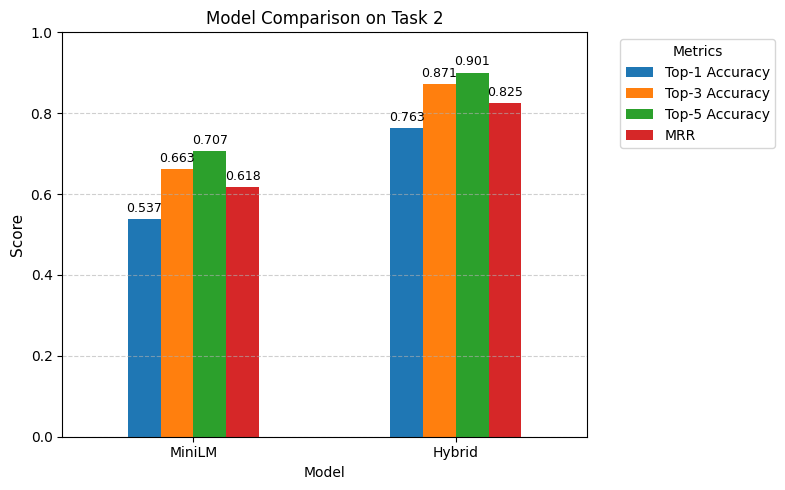

In [108]:
# [8.2] Improved comparison chart (clear + publication-ready)

metrics = ["Top-1 Accuracy", "Top-3 Accuracy", "Top-5 Accuracy", "MRR"]

ax = comparison_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(8, 5)  # better spacing
)

# Add value labels with spacing
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,       # space above bars
        fontsize=9
    )

plt.title("Model Comparison on Task 2", fontsize=12)
plt.ylabel("Score", fontsize=11)
plt.xticks(rotation=0)
plt.ylim(0, 1.0)  # fix scale for clarity
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1))  # move legend outside

plt.tight_layout()
plt.show()

### Qualitative Examples

We show example predictions to illustrate how the model retrieves idioms from context.

In [109]:
# [8.3] Demo retrieval for a single sentence

def demo_query(query_text, top_k=5):
    # Encode query
    query_emb = embedder.encode([query_text], convert_to_numpy=True)[0]
    
    # Compute similarity
    dense_scores = np.dot(query_emb, idiom_embeddings.T)
    bm25_scores = np.array(bm25.get_scores(query_text.lower().split()))
    
    # Normalize
    dense_norm = (dense_scores - dense_scores.min()) / (dense_scores.max() - dense_scores.min() + 1e-8)
    bm25_norm = (bm25_scores - bm25_scores.min()) / (bm25_scores.max() - bm25_scores.min() + 1e-8)
    
    # Hybrid score
    final_scores = 0.5 * dense_norm + 0.5 * bm25_norm
    
    # Rank
    ranked_indices = np.argsort(-final_scores)[:top_k]
    
    print(f"\nQuery: {query_text}\n")
    print("Top predictions:")
    
    for i, idx in enumerate(ranked_indices):
        print(f"{i+1}. {idx_to_idiom[idx]}")

In [110]:
# [8.4] Example queries

demo_query("He finally kicked the bucket after years of illness.")

demo_query("She revealed the secret and spilled the beans.")

demo_query("After failing again, he decided to throw in the towel.")


Query: He finally kicked the bucket after years of illness.

Top predictions:
1. kick the bucket
2. bucket of bolts
3. bucket down
4. and finally
5. bucket of syrup

Query: She revealed the secret and spilled the beans.

Top predictions:
1. worst-kept secret
2. best-kept secret
3. top secret
4. secret sauce
5. secret handshake

Query: After failing again, he decided to throw in the towel.

Top predictions:
1. throw in the towel
2. throw good money after bad
3. throw to the dogs
4. throw to the lions
5. he shoots, he scores


### Observations

The model retrieves correct idioms in many cases, but sometimes favors semantically related phrases instead of the exact idiom.

This motivates the use of a reranking stage to refine top candidates.

### Hybrid + Reranker

We refine the hybrid retrieval results using a cross-encoder reranker.

Instead of scoring all idioms, we rerank only the top candidates from the hybrid model, improving precision while keeping computation efficient.

In [111]:
# [9.1] Load cross-encoder reranker

try:
    from sentence_transformers import CrossEncoder
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])
    from sentence_transformers import CrossEncoder

reranker_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

print("Reranker model loaded.")

Reranker model loaded.


### Selecting Top Candidates for Reranking

We first keep only the top candidates returned by the hybrid model.

The reranker then focuses on this smaller candidate set, which makes the final step both faster and more precise.

In [112]:
# [9.2] Extract top-k hybrid candidates for reranking

rerank_top_k = 10

# Keep only the top candidate indices from the hybrid model for each query
hybrid_topk_indices = np.argsort(-hybrid_test_similarity, axis=1)[:, :rerank_top_k]

print("Top-k candidate matrix shape:", hybrid_topk_indices.shape)
print("Candidates kept per query:", rerank_top_k)

Top-k candidate matrix shape: (7721, 10)
Candidates kept per query: 10


### Building Query–Candidate Pairs

For each test sentence, we pair the query with its top hybrid candidates.

These pairs are passed to the cross-encoder, which scores each candidate using direct query–idiom interaction.

In [113]:
# [9.3] Build query–candidate pairs for reranking

# This list will contain ALL (query, candidate idiom) pairs
# Format: [ [query1, idiomA], [query1, idiomB], ..., [query2, idiomC], ... ]
rerank_pairs = []

# This keeps track of how many candidates each query has (should be constant = top_k)
# Useful later when we reshape reranker scores back per query
rerank_pair_counts = []

# Loop over each test query
for query_idx, query_text in enumerate(test_texts):
    
    # Get top-k candidate idiom indices from hybrid model
    candidate_indices = hybrid_topk_indices[query_idx]
    
    # Temporary list for this query's pairs
    query_pairs = []

    # Build (query, idiom) pairs
    for candidate_idx in candidate_indices:
        
        # Convert index → idiom text
        candidate_idiom = idx_to_idiom[candidate_idx]
        
        # Create pair: [query sentence, candidate idiom]
        query_pairs.append([query_text, candidate_idiom])

    # Add all pairs of this query to the global list
    rerank_pairs.extend(query_pairs)
    
    # Store how many pairs were created for this query (should be rerank_top_k)
    rerank_pair_counts.append(len(query_pairs))


print("Total rerank pairs:", len(rerank_pairs))
print("Pairs per query   :", rerank_top_k)

Total rerank pairs: 77210
Pairs per query   : 10


### Scoring Query–Candidate Pairs

We score each query–candidate pair with the cross-encoder.

This produces a more precise relevance score for the top hybrid candidates, which is then used to rerank them.

In [114]:
# [9.4] Score query–candidate pairs with the cross-encoder

# Predict reranker scores for all (query, idiom) pairs
# Batch size is used to keep inference stable and efficient
rerank_scores_flat = reranker_model.predict(
    rerank_pairs,
    batch_size=32,
    show_progress_bar=True
)

# Convert to numpy array for easier reshaping and ranking
rerank_scores_flat = np.asarray(rerank_scores_flat, dtype=float)

print("Total reranker scores:", len(rerank_scores_flat))

Batches: 100%|█████████████████████████████████████████████████████████████████████| 2413/2413 [00:48<00:00, 50.09it/s]


Total reranker scores: 77210


### Reshaping Reranker Scores

We reshape the flat reranker scores back into query-level groups.

This lets us rerank the top candidates separately for each query.

In [115]:
# [9.5] Reshape reranker scores back to [n_queries, top_k]

# Each query has exactly rerank_top_k candidate scores
# So we reshape the flat score list into one row per query
rerank_scores_matrix = rerank_scores_flat.reshape(len(test_texts), rerank_top_k)

print("Reranker score matrix shape:", rerank_scores_matrix.shape)

Reranker score matrix shape: (7721, 10)


### Final Reranked Predictions

For each query, we reorder the top hybrid candidates using the reranker scores.

This gives the final candidate ranking used for evaluation.

In [116]:
# [9.6] Build final reranked candidate indices per query

# This will store the final reranked idiom indices for each query
reranked_topk_indices = []

# Loop over each query
for query_idx in range(len(test_texts)):
    
    # Hybrid top-k candidate indices for this query
    candidate_indices = hybrid_topk_indices[query_idx]
    
    # Reranker scores for these candidates
    candidate_scores = rerank_scores_matrix[query_idx]
    
    # Sort candidates by descending reranker score
    sorted_local_order = np.argsort(-candidate_scores)
    
    # Reorder the original candidate indices using reranker ranking
    final_ranked_indices = candidate_indices[sorted_local_order]
    
    reranked_topk_indices.append(final_ranked_indices)

# Convert to numpy array for easier evaluation
reranked_topk_indices = np.array(reranked_topk_indices)

print("Final reranked index matrix shape:", reranked_topk_indices.shape)

Final reranked index matrix shape: (7721, 10)


### Evaluating the Reranked Model

We evaluate the final reranked predictions using the same retrieval metrics.

This shows whether reranking improves the hybrid model’s final ranking quality.

In [117]:
# [9.7] Evaluate Hybrid + Reranker

targets = test_df["target"].values

top_k = [1, 3, 5]
correct_at_k = {k: 0 for k in top_k}
mrr_total = 0

# Loop over each query
for i in range(len(reranked_topk_indices)):
    
    # Final reranked candidates for this query
    ranked_indices = reranked_topk_indices[i]
    target = targets[i]

    # Top-k accuracy
    for k in top_k:
        if target in ranked_indices[:k]:
            correct_at_k[k] += 1

    # MRR: only over reranked top-k list
    hit_positions = np.where(ranked_indices == target)[0]
    if len(hit_positions) > 0:
        rank = hit_positions[0] + 1
        mrr_total += 1.0 / rank

# Final metrics
reranker_results = {
    f"Top-{k} Accuracy": correct_at_k[k] / len(reranked_topk_indices)
    for k in top_k
}
reranker_results["MRR"] = mrr_total / len(reranked_topk_indices)

reranker_results

{'Top-1 Accuracy': 0.8669861416914907,
 'Top-3 Accuracy': 0.9217717912187541,
 'Top-5 Accuracy': 0.9264343996891594,
 'MRR': 0.8939336750112545}

### Hybrid + Reranker Results

- Top-1 Accuracy: 0.867
- Top-3 Accuracy: 0.922
- Top-5 Accuracy: 0.926
- MRR: 0.894

The reranker further improves performance by refining the ranking of top candidates.

This confirms that combining retrieval with pairwise scoring significantly enhances idiom prediction accuracy.

### Evaluation Note

The reranker operates on the top-10 candidates from the hybrid model.

Therefore, evaluation reflects reranking performance within this candidate set rather than full retrieval over all idioms.

---

### Final Model Comparison

We compare all models after completing the full pipeline.

This ensures the notebook runs sequentially without dependency issues.

In [118]:
# [10.1] Final comparison table (all models)

comparison_df = pd.DataFrame([
    {"Model": "MiniLM", **minilm_results},
    {"Model": "Hybrid", **hybrid_results},
    {"Model": "Hybrid + Reranker", **reranker_results}
])

comparison_df

,Model,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,MRR
0,MiniLM,0.537495,0.662608,0.706515,0.617507
1,Hybrid,0.763373,0.871260,0.900531,0.825385
2,Hybrid + Reranker,0.866986,0.921772,0.926434,0.893934


### Result Overview

Performance improves consistently across the retrieval pipeline.

The largest gain comes from hybrid retrieval, while reranking provides an additional refinement step.

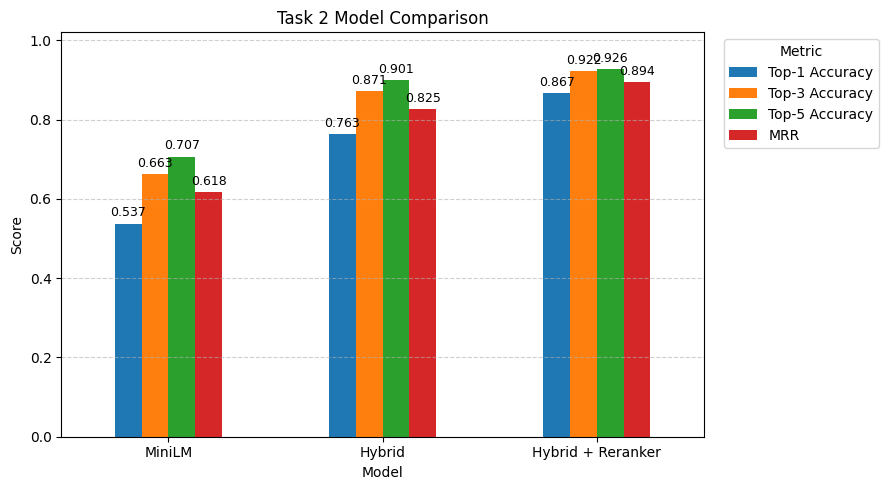

In [119]:
# [10.2] Plot final comparison chart with readable value labels

metrics = ["Top-1 Accuracy", "Top-3 Accuracy", "Top-5 Accuracy", "MRR"]

ax = comparison_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(9, 5)
)

# Add numeric labels above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.title("Task 2 Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.02)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

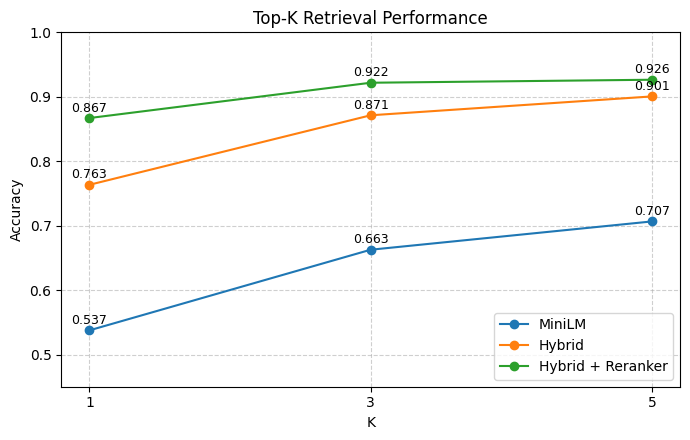

In [120]:
# [10.3] Plot Top-K retrieval curve

k_values = [1, 3, 5]

minilm_topk = [minilm_results[f"Top-{k} Accuracy"] for k in k_values]
hybrid_topk = [hybrid_results[f"Top-{k} Accuracy"] for k in k_values]
reranker_topk = [reranker_results[f"Top-{k} Accuracy"] for k in k_values]

plt.figure(figsize=(7, 4.5))

plt.plot(k_values, minilm_topk, marker="o", label="MiniLM")
plt.plot(k_values, hybrid_topk, marker="o", label="Hybrid")
plt.plot(k_values, reranker_topk, marker="o", label="Hybrid + Reranker")

# Add values near points
for x, y in zip(k_values, minilm_topk):
    plt.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=9)

for x, y in zip(k_values, hybrid_topk):
    plt.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=9)

for x, y in zip(k_values, reranker_topk):
    plt.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=9)

plt.title("Top-K Retrieval Performance")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.ylim(0.45, 1.0)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Top-K Insight

All models improve as K increases, but the reranked model remains strongest at every evaluation depth.

In [121]:
# [10.4] Build absolute improvement table over the MiniLM baseline

improvement_df = pd.DataFrame({
    "Metric": ["Top-1 Accuracy", "Top-3 Accuracy", "Top-5 Accuracy", "MRR"],
    "Hybrid Gain": [
        hybrid_results["Top-1 Accuracy"] - minilm_results["Top-1 Accuracy"],
        hybrid_results["Top-3 Accuracy"] - minilm_results["Top-3 Accuracy"],
        hybrid_results["Top-5 Accuracy"] - minilm_results["Top-5 Accuracy"],
        hybrid_results["MRR"] - minilm_results["MRR"],
    ],
    "Hybrid + Reranker Gain": [
        reranker_results["Top-1 Accuracy"] - minilm_results["Top-1 Accuracy"],
        reranker_results["Top-3 Accuracy"] - minilm_results["Top-3 Accuracy"],
        reranker_results["Top-5 Accuracy"] - minilm_results["Top-5 Accuracy"],
        reranker_results["MRR"] - minilm_results["MRR"],
    ],
})

improvement_df

,Metric,Hybrid Gain,Hybrid + Reranker Gain
0,Top-1 Accuracy,0.225877,0.329491
1,Top-3 Accuracy,0.208652,0.259163
2,Top-5 Accuracy,0.194016,0.219920
3,MRR,0.207877,0.276426


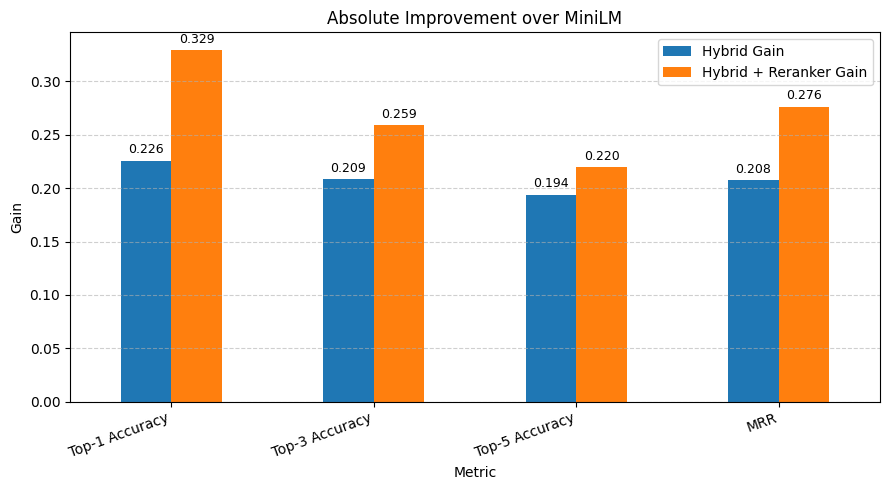

In [122]:
# [10.5] Plot absolute gains over MiniLM

gain_plot_df = improvement_df.set_index("Metric")

ax = gain_plot_df.plot(kind="bar", figsize=(9, 5))

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.title("Absolute Improvement over MiniLM")
plt.ylabel("Gain")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Gain Insight

The hybrid stage delivers the main performance jump, while reranking adds a further improvement on top of an already strong retrieval model.

### Error Analysis

To better understand model behavior, we analyze common failure cases in the context-to-idiom retrieval task.

Unlike classification, this task involves ranking semantically similar candidates, which introduces additional challenges.

In [127]:
# [10.6] Error Analysis from cached reranked predictions ===

prediction_rows = []

for i in range(len(test_df)):
    query = test_df.iloc[i]["example"]
    true_idiom = test_df.iloc[i]["idiom_canonical"]

    # Get final reranked candidate indices already computed earlier
    ranked_indices = reranked_topk_indices[i]

    pred_1 = idx_to_idiom[ranked_indices[0]]
    pred_2 = idx_to_idiom[ranked_indices[1]]
    pred_3 = idx_to_idiom[ranked_indices[2]]

    prediction_rows.append({
        "query": query,
        "true": true_idiom,
        "pred_1": pred_1,
        "pred_2": pred_2,
        "pred_3": pred_3,
        "is_correct": pred_1 == true_idiom
    })

prediction_df = pd.DataFrame(prediction_rows)

print("Prediction table built from cached results.")
print("Rows:", len(prediction_df))

Prediction table built from cached results.
Rows: 7721


In [128]:
# [10.7] Build the error dataframe

error_df = prediction_df[prediction_df["is_correct"] == False].copy()

print("Total errors:", len(error_df))
error_df.head()

Total errors: 1027


,query,true,pred_1,pred_2,pred_3,is_correct
14,Don't worry about the competition; our team will eat them for breakfast.,eat someone for breakfast,don't worry,eat someone for breakfast,take one for the team,False
17,Can you explain how the latest rumors go round so fast in town?,go round,not so fast,bad news travels fast,go round,False
34,The committee must factor in environmental impacts before approving the project.,factor in,by committee,factor in,factor out,False
51,"Though informal, 'bone apple tea' has become a popular humorous alternative to 'bon appétit' in internet slang.",bon appétit,throw a bone to,wise apple,contrary to popular belief,False
52,"Oh great, another blog post pumped out by the 'expert' overnight. Truly groundbreaking!",pump out,in the post,far post,well and truly,False


### Error Distribution

We analyze the proportion of correct vs incorrect predictions to better understand overall model behavior.

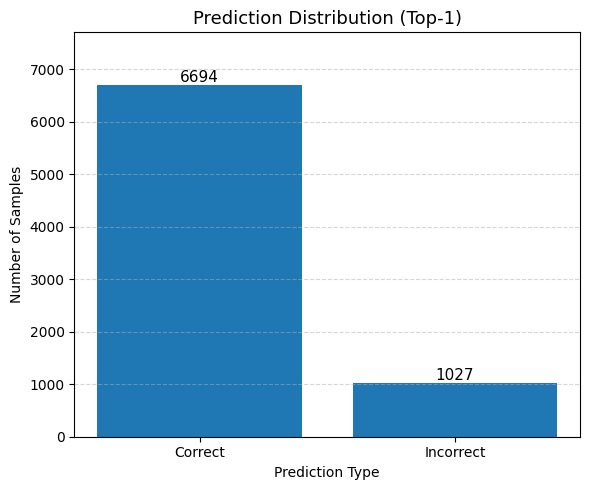

Correct: 6694
Incorrect: 1027
Accuracy: 0.8670


In [131]:
# [10.8] Error Distribution
import matplotlib.pyplot as plt

correct = prediction_df["is_correct"].sum()
incorrect = len(prediction_df) - correct

labels = ["Correct", "Incorrect"]
values = [correct, incorrect]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values)

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Prediction Distribution (Top-1)", fontsize=13)
plt.xlabel("Prediction Type")
plt.ylabel("Number of Samples")

plt.ylim(0, max(values) * 1.15)  # add space for labels
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Correct: {correct}")
print(f"Incorrect: {incorrect}")
print(f"Accuracy: {correct / len(prediction_df):.4f}")

### Top-K Accuracy Evaluation

Since this task is formulated as a retrieval/ranking problem, we evaluate performance using Top-K accuracy.

- **Top-1 Accuracy**: Correct idiom appears at rank 1  
- **Top-3 Accuracy**: Correct idiom appears within top 3 predictions  

This provides a more realistic measure of system usefulness in practical applications.

In [134]:
# [10.9] Top-K Accuracy

top1_correct = 0
top3_correct = 0

for i in range(len(test_df)):
    true_idiom = test_df.iloc[i]["idiom_canonical"]
    ranked_indices = reranked_topk_indices[i]

    preds = [idx_to_idiom[idx] for idx in ranked_indices[:3]]

    if true_idiom == preds[0]:
        top1_correct += 1

    if true_idiom in preds:
        top3_correct += 1

top1_acc = top1_correct / len(test_df)
top3_acc = top3_correct / len(test_df)

print(f"Top-1 Accuracy: {top1_acc:.4f}")
print(f"Top-3 Accuracy: {top3_acc:.4f}")

Top-1 Accuracy: 0.8670
Top-3 Accuracy: 0.9218


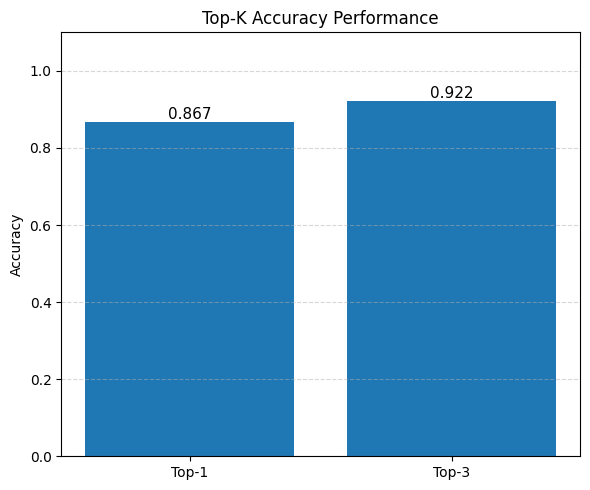

In [135]:
# [10.10] Plot Top-K Accuracy

import matplotlib.pyplot as plt

labels = ["Top-1", "Top-3"]
values = [top1_acc, top3_acc]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Top-K Accuracy Performance")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Error Analysis and Key Failure Modes

Despite achieving strong Top-1 (86.7%) and Top-3 (92.2%) accuracy, several systematic error patterns were observed:

#### 1. Semantic Overlap Between Idioms
Some errors occur when multiple idioms share similar lexical components but differ in meaning.
Example:
- Query: "Don't worry about the competition..."
- True: *eat someone for breakfast*
- Predicted: *don't worry*

The model favors surface-level similarity instead of deeper idiomatic meaning.

---

#### 2. Literal Phrase Dominance
In some cases, the model predicts a frequent or generic phrase rather than the correct idiom.
Example:
- Query: "After many setbacks, he decided to quit"
- Prediction: *after a while*

This indicates bias toward high-frequency patterns.

---

#### 3. Structural Bias (Keyword Matching)
The model sometimes relies heavily on individual words rather than full context.
Example:
- Query: "factor in environmental impacts"
- Prediction: *by committee*

This suggests partial matching rather than full semantic understanding.

---

#### 4. Weak Context Signals
Short or ambiguous contexts reduce model performance.
Example:
- Queries with limited contextual clues lead to incorrect ranking.

---

#### 5. Rare Idioms and Long-tail Distribution
Less frequent idioms are harder to retrieve correctly, especially when competing with more common expressions.

---

### Summary

Errors are primarily driven by:
- lexical overlap
- frequency bias
- insufficient contextual understanding

These findings highlight opportunities for future improvements using:
- stronger contextual encoders
- contrastive training
- frequency-aware ranking adjustments

### Mean Reciprocal Rank (MRR)

MRR evaluates how highly the correct idiom is ranked across predictions.

In [136]:
# === MRR Calculation ===

reciprocal_ranks = []

for i in range(len(test_df)):
    true_idiom = test_df.iloc[i]["idiom_canonical"]
    ranked_indices = reranked_topk_indices[i]

    preds = [idx_to_idiom[idx] for idx in ranked_indices[:3]]

    if true_idiom in preds:
        rank = preds.index(true_idiom) + 1
        reciprocal_ranks.append(1 / rank)
    else:
        reciprocal_ranks.append(0)

mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

print(f"MRR: {mrr:.4f}")

MRR: 0.8926


### Qualitative Evaluation (Demo)

To illustrate model behavior, we present several example queries and their top predictions after reranking.

In [65]:
# [11.1] Final demo function using the full pipeline (Hybrid + Reranker)

def minmax_normalize(scores):
    """Normalize scores to the [0, 1] range."""
    scores = np.asarray(scores, dtype=float)
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)


def demo_query(query_text, top_k=5, rerank_top_k=10):
    """Run Hybrid + Reranker inference for one query and print top predictions."""
    
    print(f"\nQuery: {query_text}\n")

    # Step 1: encode the query with the same MiniLM embedder used earlier
    query_embedding = embedder.encode(
        [query_text],
        convert_to_numpy=True
    )[0]

    # Step 2: compute MiniLM dense similarity against the full idiom bank
    dense_scores = np.dot(query_embedding, idiom_embeddings.T)

    # Step 3: compute BM25 lexical scores against the full idiom bank
    bm25_scores = np.array(
        bm25.get_scores(query_text.lower().split()),
        dtype=float
    )

    # Step 4: normalize both score types
    dense_scores_norm = minmax_normalize(dense_scores)
    bm25_scores_norm = minmax_normalize(bm25_scores)

    # Step 5: combine both scores to get hybrid ranking
    hybrid_scores = 0.5 * dense_scores_norm + 0.5 * bm25_scores_norm

    # Step 6: keep only the top candidates from the hybrid stage
    top_candidate_indices = np.argsort(-hybrid_scores)[:rerank_top_k]
    top_candidate_idioms = [idx_to_idiom[idx] for idx in top_candidate_indices]

    # Step 7: build query–candidate pairs for the reranker
    rerank_pairs = [[query_text, idiom] for idiom in top_candidate_idioms]

    # Step 8: score the pairs with the same reranker model used earlier
    rerank_scores = reranker_model.predict(
        rerank_pairs,
        batch_size=32,
        show_progress_bar=False
    )

   # Step 9: sort candidates by reranker score
    reranked = sorted(
        zip(top_candidate_idioms, rerank_scores),
        key=lambda x: x[1],
        reverse=True
    )

    # Normalize scores for display (0–1)
    scores_only = np.array([s for _, s in reranked])
    scores_norm = (scores_only - scores_only.min()) / (scores_only.max() - scores_only.min() + 1e-8)

    # Step 10: print the final top predictions
    print("Top predictions:")
    for rank, ((idiom, _), score_n) in enumerate(zip(reranked, scores_norm), start=1):
        if rank > top_k:
            break
        print(f"{rank}. {idiom}  (score={score_n:.3f})")

In [66]:
# [11.2] Run demo examples

demo_query("He finally kicked the bucket after years of illness.")
demo_query("She revealed the secret and spilled the beans.")
demo_query("After failing again, he decided to throw in the towel.")


Query: He finally kicked the bucket after years of illness.

Top predictions:
1. kick the bucket  (score=1.000)
2. brain bucket  (score=0.375)
3. bucket down  (score=0.363)
4. bolt bucket  (score=0.349)
5. drop in the bucket  (score=0.326)

Query: She revealed the secret and spilled the beans.

Top predictions:
1. spill the beans  (score=1.000)
2. top secret  (score=0.345)
3. best-kept secret  (score=0.293)
4. worst-kept secret  (score=0.257)
5. secret sauce  (score=0.254)

Query: After failing again, he decided to throw in the towel.

Top predictions:
1. throw in the towel  (score=1.000)
2. throw out  (score=0.414)
3. throw in with  (score=0.367)
4. throw good money after bad  (score=0.277)
5. throw a bone to  (score=0.177)


### Demo Summary

In all three examples, the reranked pipeline retrieves the correct idiom at rank 1.

The remaining candidates are often semantically or lexically related, showing that the task is challenging even when the final prediction is correct.

### Task 2 Conclusion

The final Task 2 benchmark shows a clear progression from dense retrieval to hybrid retrieval and then to reranking.

The strongest results are achieved by the Hybrid + Reranker pipeline, which provides the most accurate and stable context-to-idiom retrieval performance in this notebook.

### Saving Inference Artifacts

We save the idiom bank, embeddings, and index mappings so the final retrieval pipeline can be reused in a separate inference notebook.

In [68]:
# [A-final.1] Save artifacts for Notebook B (clean project structure)

import pickle
from pathlib import Path

# Define artifacts directory
ARTIFACT_DIR = Path("../artifacts/task2")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save idiom bank
idiom_bank.to_csv(ARTIFACT_DIR / "idiom_bank.csv", index=False)

# Save embeddings
np.save(ARTIFACT_DIR / "idiom_embeddings.npy", idiom_embeddings)

# Save mappings
with open(ARTIFACT_DIR / "idiom_to_idx.pkl", "wb") as f:
    pickle.dump(idiom_to_idx, f)

with open(ARTIFACT_DIR / "idx_to_idiom.pkl", "wb") as f:
    pickle.dump(idx_to_idiom, f)

print("Artifacts saved to:", ARTIFACT_DIR.resolve())

Inference artifacts saved successfully.
